# Full Attribution Results Analysis

This notebook analyzes the full attribution task results, where different LLM judges try to identify which of two code snippets was generated by which model.

In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

## 1. Load Data

In [2]:
def load_attribution_results(base_dir: Path) -> list[dict]:
    """Load all full attribution results from the directory."""
    results = []
    
    # Find all JSONL files recursively
    for jsonl_file in base_dir.rglob("judge-*.jsonl"):
        # Extract benchmark from path: data/full_attribution/<benchmark>/test/<file>.jsonl
        benchmark = jsonl_file.parent.parent.name
        
        with open(jsonl_file, 'r') as f:
            for line in f:
                line = line.strip()
                if line:
                    record = json.loads(line)
                    # Add source file info for debugging
                    record['source_file'] = str(jsonl_file)
                    record['benchmark'] = benchmark
                    results.append(record)
    
    return results

# Load data
base_dir = Path("../data/full_attribution")
results = load_attribution_results(base_dir)
print(f"Loaded {len(results)} attribution records")

Loaded 3031 attribution records


In [3]:
# Convert to DataFrame
df = pd.DataFrame(results)

# Convert is_correct to boolean (handles mixed types from JSON)
def parse_is_correct(x):
    """Convert various representations to boolean."""
    if x is None:
        return pd.NA
    if isinstance(x, bool):
        return x
    if isinstance(x, (int, float)):
        return bool(x)
    if isinstance(x, str):
        return x.lower() in ('true', '1', 'yes')
    return pd.NA

df['is_correct'] = df['is_correct'].apply(parse_is_correct).astype('boolean')
# Clean model names (remove provider prefix)
def clean_model_name(model_name: str) -> str:
    """Extract clean model name from full model identifier."""
    if model_name and '/' in model_name:
        return model_name.split('/')[-1]
    return model_name if model_name else 'unknown'
df['judge_short'] = df['judge_model'].apply(clean_model_name)
df['model1_short'] = df['model1'].apply(clean_model_name)
df['model2_short'] = df['model2'].apply(clean_model_name)
# Create model pair identifier
df['model_pair'] = df.apply(lambda x: tuple(sorted([x['model1_short'], x['model2_short']])), axis=1)
df['model_pair_str'] = df['model_pair'].apply(lambda x: f"{x[0]} vs {x[1]}")
print(f"DataFrame shape: {df.shape}")
df.head()

DataFrame shape: (3031, 14)


,benchmark,task_id,judge_model,model1,model2,predicted_attribution,gold_attribution,is_correct,source_file,judge_short,model1_short,model2_short,model_pair,model_pair_str
0,mbpp-sanitized,56,qwen/qwen3-coder-30b-a3b-instruct,deepseek/deepseek-chat-v3-0324,anthropic/claude-haiku-4.5,"{'Code1': 'anthropic/claude-haiku-4.5', 'Code2...","{'Code1': 'deepseek/deepseek-chat-v3-0324', 'C...",False,../data/full_attribution/mbpp-sanitized/test/j...,qwen3-coder-30b-a3b-instruct,deepseek-chat-v3-0324,claude-haiku-4.5,"(claude-haiku-4.5, deepseek-chat-v3-0324)",claude-haiku-4.5 vs deepseek-chat-v3-0324
1,mbpp-sanitized,61,qwen/qwen3-coder-30b-a3b-instruct,anthropic/claude-haiku-4.5,deepseek/deepseek-chat-v3-0324,"{'Code1': 'anthropic/claude-haiku-4.5', 'Code2...","{'Code1': 'anthropic/claude-haiku-4.5', 'Code2...",True,../data/full_attribution/mbpp-sanitized/test/j...,qwen3-coder-30b-a3b-instruct,claude-haiku-4.5,deepseek-chat-v3-0324,"(claude-haiku-4.5, deepseek-chat-v3-0324)",claude-haiku-4.5 vs deepseek-chat-v3-0324
2,mbpp-sanitized,17,qwen/qwen3-coder-30b-a3b-instruct,anthropic/claude-haiku-4.5,deepseek/deepseek-chat-v3-0324,"{'Code1': 'anthropic/claude-haiku-4.5', 'Code2...","{'Code1': 'anthropic/claude-haiku-4.5', 'Code2...",True,../data/full_attribution/mbpp-sanitized/test/j...,qwen3-coder-30b-a3b-instruct,claude-haiku-4.5,deepseek-chat-v3-0324,"(claude-haiku-4.5, deepseek-chat-v3-0324)",claude-haiku-4.5 vs deepseek-chat-v3-0324
3,mbpp-sanitized,88,qwen/qwen3-coder-30b-a3b-instruct,anthropic/claude-haiku-4.5,deepseek/deepseek-chat-v3-0324,"{'Code1': 'anthropic/claude-haiku-4.5', 'Code2...","{'Code1': 'anthropic/claude-haiku-4.5', 'Code2...",True,../data/full_attribution/mbpp-sanitized/test/j...,qwen3-coder-30b-a3b-instruct,claude-haiku-4.5,deepseek-chat-v3-0324,"(claude-haiku-4.5, deepseek-chat-v3-0324)",claude-haiku-4.5 vs deepseek-chat-v3-0324
4,mbpp-sanitized,84,qwen/qwen3-coder-30b-a3b-instruct,anthropic/claude-haiku-4.5,deepseek/deepseek-chat-v3-0324,"{'Code1': 'anthropic/claude-haiku-4.5', 'Code2...","{'Code1': 'anthropic/claude-haiku-4.5', 'Code2...",True,../data/full_attribution/mbpp-sanitized/test/j...,qwen3-coder-30b-a3b-instruct,claude-haiku-4.5,deepseek-chat-v3-0324,"(claude-haiku-4.5, deepseek-chat-v3-0324)",claude-haiku-4.5 vs deepseek-chat-v3-0324


## 2. Overview Statistics

In [4]:
# Filter out null predictions
df_valid = df[df['is_correct'].notna()].copy()
print(f"Valid records (non-null predictions): {len(df_valid)} / {len(df)}")

# Overall accuracy
overall_accuracy = df_valid['is_correct'].mean() * 100
print(f"\nOverall Attribution Accuracy: {overall_accuracy:.2f}%")

# By benchmark
print("\nAccuracy by Benchmark:")
benchmark_acc = df_valid.groupby('benchmark')['is_correct'].agg(['mean', 'count'])
benchmark_acc['accuracy'] = (benchmark_acc['mean'] * 100).round(2)
print(benchmark_acc[['count', 'accuracy']])

Valid records (non-null predictions): 3002 / 3031

Overall Attribution Accuracy: 64.36%

Accuracy by Benchmark:
                count  accuracy
benchmark                      
ds1000            150     55.33
humaneval         492     52.24
mbpp-sanitized   2360     67.46


In [5]:
# List unique judges and model pairs
print("Unique Judges:")
for judge in sorted(df_valid['judge_short'].unique()):
    count = len(df_valid[df_valid['judge_short'] == judge])
    print(f"  - {judge}: {count} evaluations")

print("\nUnique Model Pairs Being Classified:")
for pair in sorted(df_valid['model_pair_str'].unique()):
    count = len(df_valid[df_valid['model_pair_str'] == pair])
    print(f"  - {pair}: {count} evaluations")

Unique Judges:
  - claude-sonnet-4.5: 257 evaluations
  - gemini-2.5-flash: 257 evaluations
  - gemini-3-pro-preview: 55 evaluations
  - gpt-5: 764 evaluations
  - gpt-5.1-codex: 257 evaluations
  - grok-4.1-fast: 257 evaluations
  - grok-code-fast-1: 898 evaluations
  - qwen3-coder-30b-a3b-instruct: 257 evaluations

Unique Model Pairs Being Classified:
  - claude-haiku-4.5 vs deepseek-chat-v3-0324: 2419 evaluations
  - claude-haiku-4.5 vs gpt-5: 419 evaluations
  - deepseek-chat-v3-0324 vs grok-4-fast: 164 evaluations


## 3. Judge Performance Analysis

In [6]:
# Accuracy by judge model
judge_stats = df_valid.groupby('judge_short').agg(
    total_tasks=('is_correct', 'count'),
    correct=('is_correct', 'sum')
).reset_index()

judge_stats['accuracy'] = (judge_stats['correct'] / judge_stats['total_tasks'] * 100).round(2)
judge_stats = judge_stats.sort_values('accuracy', ascending=False)

print("Judge Model Performance (Overall):")
print(judge_stats.to_string(index=False))

Judge Model Performance (Overall):
                 judge_short  total_tasks  correct  accuracy
           claude-sonnet-4.5          257      199     77.43
               grok-4.1-fast          257      192     74.71
               gpt-5.1-codex          257      178     69.26
                       gpt-5          764      500     65.45
        gemini-3-pro-preview           55       35     63.64
            grok-code-fast-1          898      546      60.8
qwen3-coder-30b-a3b-instruct          257      150     58.37
            gemini-2.5-flash          257      132     51.36


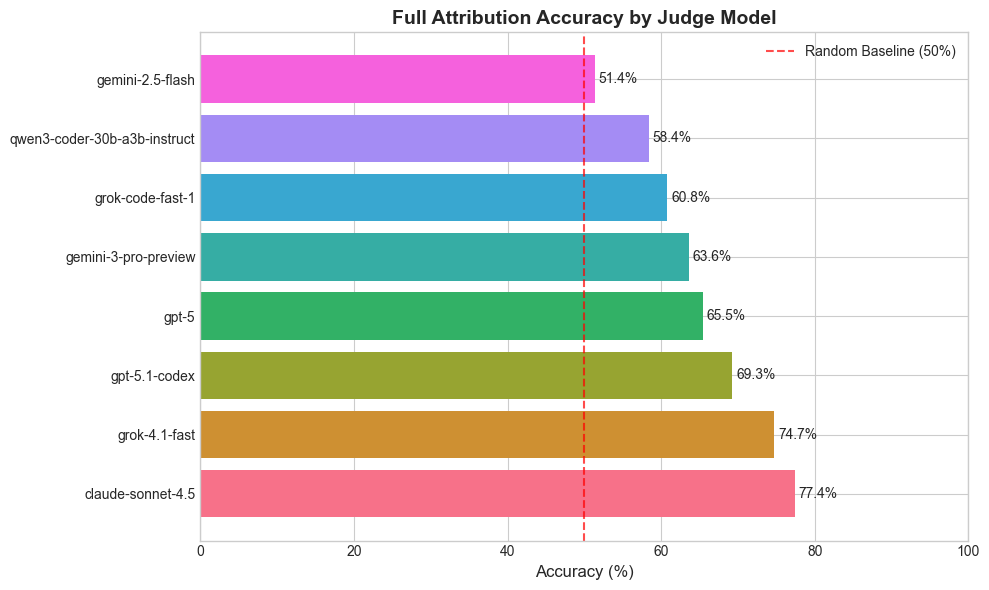

In [7]:
# Visualize judge performance
fig, ax = plt.subplots(figsize=(10, 6))

colors = sns.color_palette('husl', len(judge_stats))
bars = ax.barh(judge_stats['judge_short'], judge_stats['accuracy'], color=colors)

# Add value labels
for bar, acc in zip(bars, judge_stats['accuracy']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{acc:.1f}%', va='center', fontsize=10)

ax.set_xlabel('Accuracy (%)', fontsize=12)
ax.set_title('Full Attribution Accuracy by Judge Model', fontsize=14, fontweight='bold')
ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, label='Random Baseline (50%)')
ax.legend()
ax.set_xlim(0, 100)

plt.tight_layout()
plt.show()

## 4. Judge × Benchmark Performance

In [8]:
# Accuracy by judge and benchmark
judge_benchmark_stats = df_valid.groupby(['judge_short', 'benchmark']).agg(
    total=('is_correct', 'count'),
    correct=('is_correct', 'sum')
).reset_index()

judge_benchmark_stats['accuracy'] = (judge_benchmark_stats['correct'] / judge_benchmark_stats['total'] * 100).round(2)

# Create pivot table for heatmap
pivot_accuracy = judge_benchmark_stats.pivot(index='judge_short', columns='benchmark', values='accuracy')
pivot_accuracy = pivot_accuracy.fillna(0)

# Calculate overall accuracy for sorting
pivot_accuracy['Overall'] = df_valid.groupby('judge_short')['is_correct'].mean() * 100
pivot_accuracy = pivot_accuracy.sort_values('Overall', ascending=False)

print("Accuracy by Judge and Benchmark:")
print(pivot_accuracy.round(2).to_string())

Accuracy by Judge and Benchmark:
benchmark                     ds1000  humaneval  mbpp-sanitized  Overall
judge_short                                                             
claude-sonnet-4.5                0.0        0.0           77.43    77.43
grok-4.1-fast                    0.0        0.0           74.71    74.71
gpt-5.1-codex                    0.0        0.0           69.26    69.26
gpt-5                            0.0        0.0           65.45    65.45
gemini-3-pro-preview             0.0        0.0           63.64    63.64
grok-code-fast-1               55.33      52.24           80.47     60.8
qwen3-coder-30b-a3b-instruct     0.0        0.0           58.37    58.37
gemini-2.5-flash                 0.0        0.0           51.36    51.36


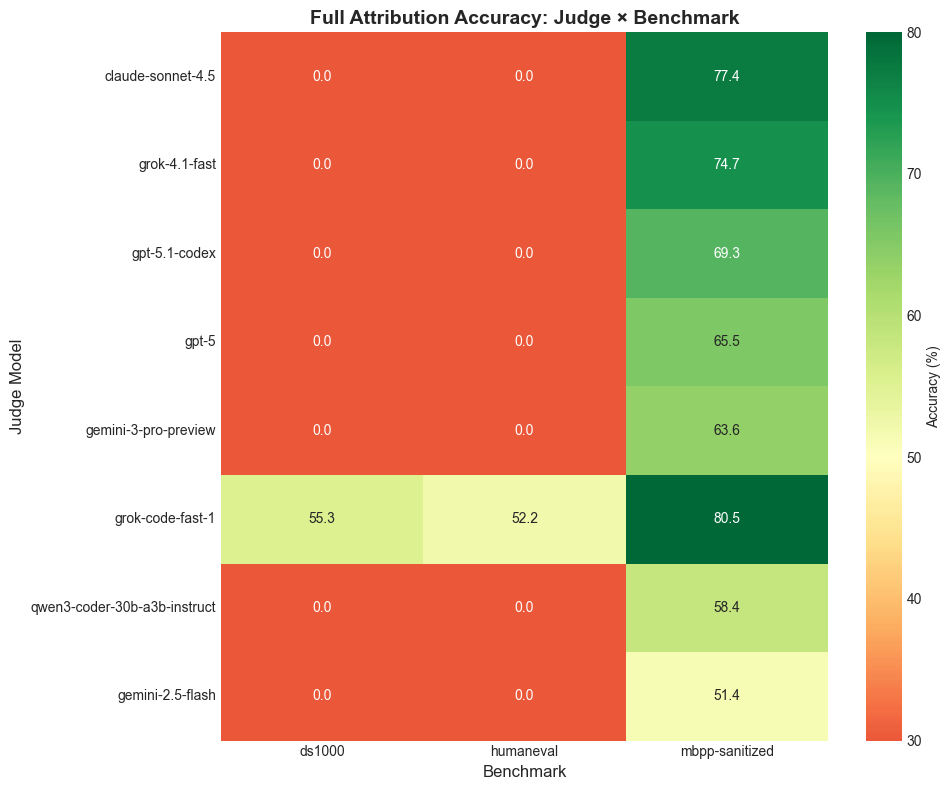

In [9]:
# Heatmap visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Remove 'Overall' column for heatmap and convert to float
heatmap_data = pivot_accuracy.drop(columns=['Overall'], errors='ignore').astype(float)

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=50, vmin=30, vmax=80, ax=ax,
            cbar_kws={'label': 'Accuracy (%)'})

ax.set_title('Full Attribution Accuracy: Judge × Benchmark', fontsize=14, fontweight='bold')
ax.set_xlabel('Benchmark', fontsize=12)
ax.set_ylabel('Judge Model', fontsize=12)

plt.tight_layout()
plt.show()

## 5. Judge × Model Pair Performance

In [10]:
# Accuracy by judge and model pair
judge_pair_stats = df_valid.groupby(['judge_short', 'model_pair_str']).agg(
    total=('is_correct', 'count'),
    correct=('is_correct', 'sum')
).reset_index()

judge_pair_stats['accuracy'] = (judge_pair_stats['correct'] / judge_pair_stats['total'] * 100).round(2)

# Pivot for heatmap
pivot_pair = judge_pair_stats.pivot(index='judge_short', columns='model_pair_str', values='accuracy')
pivot_pair = pivot_pair.fillna(0)

print("Accuracy by Judge and Model Pair:")
print(pivot_pair.round(2).to_string())

Accuracy by Judge and Model Pair:
model_pair_str                claude-haiku-4.5 vs deepseek-chat-v3-0324  claude-haiku-4.5 vs gpt-5  deepseek-chat-v3-0324 vs grok-4-fast
judge_short                                                                                                                             
claude-sonnet-4.5                                                 77.43                        0.0                                   0.0
gemini-2.5-flash                                                  51.36                        0.0                                   0.0
gemini-3-pro-preview                                              63.64                        0.0                                   0.0
gpt-5                                                             64.83                      66.67                                   0.0
gpt-5.1-codex                                                     69.26                        0.0                                   0.0
grok-4.

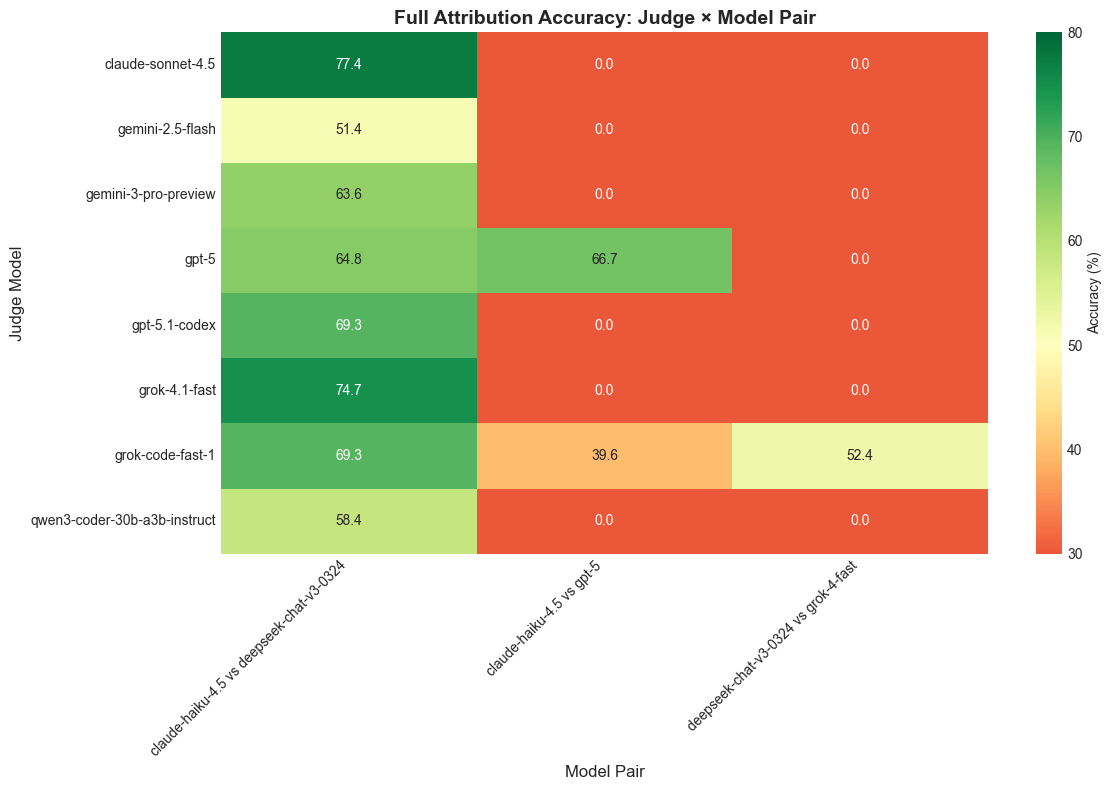

In [11]:
# Heatmap for judge × model pair (if there are multiple pairs)
if len(pivot_pair.columns) > 1:
    fig, ax = plt.subplots(figsize=(12, 8))
    
    sns.heatmap(pivot_pair.astype(float), annot=True, fmt='.1f', cmap='RdYlGn', 
                center=50, vmin=30, vmax=80, ax=ax,
                cbar_kws={'label': 'Accuracy (%)'})
    
    ax.set_title('Full Attribution Accuracy: Judge × Model Pair', fontsize=14, fontweight='bold')
    ax.set_xlabel('Model Pair', fontsize=12)
    ax.set_ylabel('Judge Model', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    
    plt.tight_layout()
    plt.show()

## 6. Confusion Analysis: Which Models Are Confused?

In [12]:
# Analyze which code positions get confused
# When incorrect, does the judge tend to always predict one model for Code1?

incorrect_df = df_valid[df_valid['is_correct'] == False].copy()

print(f"Total incorrect predictions: {len(incorrect_df)}")
print(f"\nIncorrect predictions by Judge:")
print(incorrect_df.groupby('judge_short').size().sort_values(ascending=False))

Total incorrect predictions: 1070

Incorrect predictions by Judge:
judge_short
grok-code-fast-1                352
gpt-5                           264
gemini-2.5-flash                125
qwen3-coder-30b-a3b-instruct    107
gpt-5.1-codex                    79
grok-4.1-fast                    65
claude-sonnet-4.5                58
gemini-3-pro-preview             20
dtype: int64


In [13]:
# Analyze prediction patterns
def analyze_prediction_pattern(row):
    """Analyze if the judge has a bias towards predicting certain models."""
    if row['predicted_attribution'] is None:
        return None
    
    pred = row['predicted_attribution']
    gold = row['gold_attribution']
    
    # Get which model was incorrectly predicted for Code1
    if not row['is_correct'] and pred and gold:
        # The judge thought Code1 was from this model
        predicted_code1 = clean_model_name(pred.get('Code1', ''))
        actual_code1 = clean_model_name(gold.get('Code1', ''))
        return f"Predicted {predicted_code1}, Actually {actual_code1}"
    return None

incorrect_df['error_type'] = incorrect_df.apply(analyze_prediction_pattern, axis=1)

print("\nError patterns (what judge predicted for Code1 vs actual):")
error_counts = incorrect_df['error_type'].value_counts()
print(error_counts.head(10))


Error patterns (what judge predicted for Code1 vs actual):
error_type
Predicted claude-haiku-4.5, Actually deepseek-chat-v3-0324    662
Predicted deepseek-chat-v3-0324, Actually claude-haiku-4.5    144
Predicted gpt-5, Actually claude-haiku-4.5                    111
Predicted claude-haiku-4.5, Actually gpt-5                     73
Predicted grok-4-fast, Actually deepseek-chat-v3-0324          69
Predicted deepseek-chat-v3-0324, Actually grok-4-fast           9
Predicted claude-haude-4.5, Actually deepseek-chat-v3-0324      2
Name: count, dtype: int64


## 7. Statistical Significance: Is Performance Above Chance?

In [14]:
from scipy import stats

# Test if each judge's performance is significantly above 50% (random)
print("Binomial Test: Is accuracy significantly above 50% (random)?")
print("=" * 60)

for judge in sorted(df_valid['judge_short'].unique()):
    judge_data = df_valid[df_valid['judge_short'] == judge]
    n_correct = int(judge_data['is_correct'].sum())
    n_total = len(judge_data)
    
    # One-sided binomial test (is it significantly > 50%?)
    result = stats.binomtest(n_correct, n_total, p=0.5, alternative='greater')
    
    sig = "***" if result.pvalue < 0.001 else "**" if result.pvalue < 0.01 else "*" if result.pvalue < 0.05 else ""
    
    print(f"{judge:35} {n_correct}/{n_total} ({n_correct/n_total*100:.1f}%) p={result.pvalue:.4f} {sig}")

Binomial Test: Is accuracy significantly above 50% (random)?
claude-sonnet-4.5                   199/257 (77.4%) p=0.0000 ***
gemini-2.5-flash                    132/257 (51.4%) p=0.3541 
gemini-3-pro-preview                35/55 (63.6%) p=0.0290 *
gpt-5                               500/764 (65.4%) p=0.0000 ***
gpt-5.1-codex                       178/257 (69.3%) p=0.0000 ***
grok-4.1-fast                       192/257 (74.7%) p=0.0000 ***
grok-code-fast-1                    546/898 (60.8%) p=0.0000 ***
qwen3-coder-30b-a3b-instruct        150/257 (58.4%) p=0.0043 **


## 8. Summary Table

In [15]:
# Create comprehensive summary
summary_data = []

for judge in sorted(df_valid['judge_short'].unique()):
    judge_data = df_valid[df_valid['judge_short'] == judge]
    n_total = len(judge_data)
    n_correct = int(judge_data['is_correct'].sum())
    accuracy = n_correct / n_total * 100
    
    # Get accuracy by benchmark
    bench_acc = {}
    for bench in df_valid['benchmark'].unique():
        bench_data = judge_data[judge_data['benchmark'] == bench]
        if len(bench_data) > 0:
            bench_acc[bench] = bench_data['is_correct'].mean() * 100
        else:
            bench_acc[bench] = None
    
    summary_data.append({
        'Judge': judge,
        'Total': n_total,
        'Correct': n_correct,
        'Accuracy (%)': round(accuracy, 2),
        **{f'{k} (%)': round(v, 2) if v else '-' for k, v in bench_acc.items()}
    })

summary_df = pd.DataFrame(summary_data)
summary_df = summary_df.sort_values('Accuracy (%)', ascending=False)
summary_df['Rank'] = range(1, len(summary_df) + 1)

# Reorder columns
cols = ['Rank', 'Judge', 'Total', 'Correct', 'Accuracy (%)']
cols += [c for c in summary_df.columns if c not in cols]
summary_df = summary_df[cols]

print("=" * 80)
print("FULL ATTRIBUTION RESULTS SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))

FULL ATTRIBUTION RESULTS SUMMARY
 Rank                        Judge  Total  Correct  Accuracy (%)  mbpp-sanitized (%) ds1000 (%) humaneval (%)
    1            claude-sonnet-4.5    257      199         77.43               77.43          -             -
    2                grok-4.1-fast    257      192         74.71               74.71          -             -
    3                gpt-5.1-codex    257      178         69.26               69.26          -             -
    4                        gpt-5    764      500         65.45               65.45          -             -
    5         gemini-3-pro-preview     55       35         63.64               63.64          -             -
    6             grok-code-fast-1    898      546         60.80               80.47      55.33         52.24
    7 qwen3-coder-30b-a3b-instruct    257      150         58.37               58.37          -             -
    8             gemini-2.5-flash    257      132         51.36               51.36   

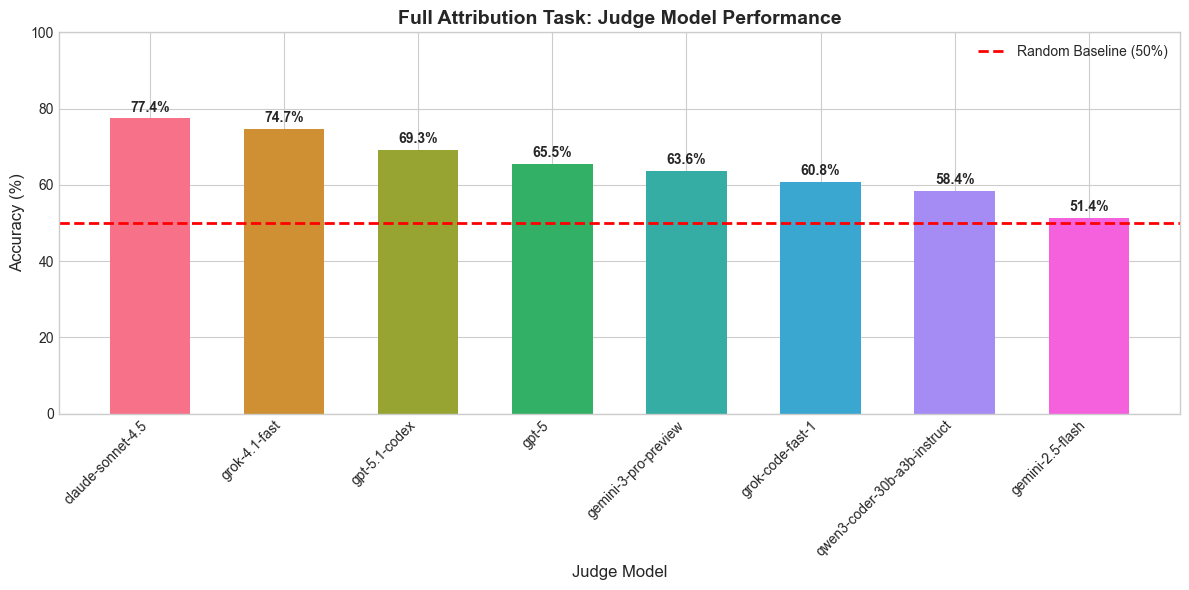

In [16]:
# Final visualization: comparison bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(summary_df))
width = 0.6

bars = ax.bar(x, summary_df['Accuracy (%)'], width, color=sns.color_palette('husl', len(summary_df)))

# Add the 50% baseline
ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random Baseline (50%)')

# Add value labels on bars
for bar, acc in zip(bars, summary_df['Accuracy (%)']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Judge Model', fontsize=12)
ax.set_title('Full Attribution Task: Judge Model Performance', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(summary_df['Judge'], rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## 9. Key Insights

In [17]:
print("=" * 80)
print("KEY INSIGHTS")
print("=" * 80)

# Best performing judge
best_judge = summary_df.iloc[0]
print(f"\n1. Best Judge: {best_judge['Judge']} with {best_judge['Accuracy (%)']:.1f}% accuracy")

# Worst performing judge
worst_judge = summary_df.iloc[-1]
print(f"2. Worst Judge: {worst_judge['Judge']} with {worst_judge['Accuracy (%)']:.1f}% accuracy")

# Overall performance
print(f"\n3. Overall Performance:")
print(f"   - Mean accuracy across all judges: {summary_df['Accuracy (%)'].mean():.1f}%")
print(f"   - All judges perform {'above' if summary_df['Accuracy (%)'].min() > 50 else 'around'} random baseline (50%)")

# Benchmark difficulty
print(f"\n4. Benchmark Analysis:")
for bench in df_valid['benchmark'].unique():
    bench_acc = df_valid[df_valid['benchmark'] == bench]['is_correct'].mean() * 100
    print(f"   - {bench}: {bench_acc:.1f}% average accuracy")

KEY INSIGHTS

1. Best Judge: claude-sonnet-4.5 with 77.4% accuracy
2. Worst Judge: gemini-2.5-flash with 51.4% accuracy

3. Overall Performance:
   - Mean accuracy across all judges: 65.1%
   - All judges perform above random baseline (50%)

4. Benchmark Analysis:
   - mbpp-sanitized: 67.5% average accuracy
   - ds1000: 55.3% average accuracy
   - humaneval: 52.2% average accuracy


## 10. Per-Dataset Detailed Analysis


In [18]:
# Analyze each dataset separately
benchmarks = sorted(df_valid['benchmark'].unique())
print(f"Datasets available: {benchmarks}\n")

for benchmark in benchmarks:
    print("=" * 80)
    print(f"DATASET: {benchmark.upper()}")
    print("=" * 80)
    
    # Filter data for this benchmark
    bench_df = df_valid[df_valid['benchmark'] == benchmark].copy()
    
    # Basic stats
    n_total = len(bench_df)
    n_correct = int(bench_df['is_correct'].sum())
    accuracy = n_correct / n_total * 100
    
    print(f"\nTotal evaluations: {n_total}")
    print(f"Correct: {n_correct} ({accuracy:.2f}%)")
    
    # Judge performance for this benchmark
    print(f"\nJudge Performance on {benchmark}:")
    print("-" * 50)
    
    judge_stats_bench = bench_df.groupby('judge_short').agg(
        total=('is_correct', 'count'),
        correct=('is_correct', 'sum')
    ).reset_index()
    
    judge_stats_bench['accuracy'] = (judge_stats_bench['correct'] / judge_stats_bench['total'] * 100).round(2)
    judge_stats_bench = judge_stats_bench.sort_values('accuracy', ascending=False)
    
    for _, row in judge_stats_bench.iterrows():
        above_chance = "✓" if row['accuracy'] > 50 else "✗"
        print(f"  {row['judge_short']:35} {row['correct']:3}/{row['total']:3} ({row['accuracy']:5.1f}%) {above_chance}")
    
    # Model pairs for this benchmark
    print(f"\nModel Pairs in {benchmark}:")
    print("-" * 50)
    
    pair_stats_bench = bench_df.groupby('model_pair_str').agg(
        total=('is_correct', 'count'),
        correct=('is_correct', 'sum')
    ).reset_index()
    
    pair_stats_bench['accuracy'] = (pair_stats_bench['correct'] / pair_stats_bench['total'] * 100).round(2)
    
    for _, row in pair_stats_bench.iterrows():
        print(f"  {row['model_pair_str']:45} {row['correct']:3}/{row['total']:3} ({row['accuracy']:5.1f}%)")
    
    print()


Datasets available: ['ds1000', 'humaneval', 'mbpp-sanitized']

DATASET: DS1000

Total evaluations: 150
Correct: 83 (55.33%)

Judge Performance on ds1000:
--------------------------------------------------
  grok-code-fast-1                     83/150 ( 55.3%) ✓

Model Pairs in ds1000:
--------------------------------------------------
  claude-haiku-4.5 vs deepseek-chat-v3-0324      83/150 ( 55.3%)

DATASET: HUMANEVAL

Total evaluations: 492
Correct: 257 (52.24%)

Judge Performance on humaneval:
--------------------------------------------------
  grok-code-fast-1                    257/492 ( 52.2%) ✓

Model Pairs in humaneval:
--------------------------------------------------
  claude-haiku-4.5 vs deepseek-chat-v3-0324     106/164 ( 64.6%)
  claude-haiku-4.5 vs gpt-5                      65/164 ( 39.6%)
  deepseek-chat-v3-0324 vs grok-4-fast           86/164 ( 52.4%)

DATASET: MBPP-SANITIZED

Total evaluations: 2360
Correct: 1592 (67.46%)

Judge Performance on mbpp-sanitized:
-------

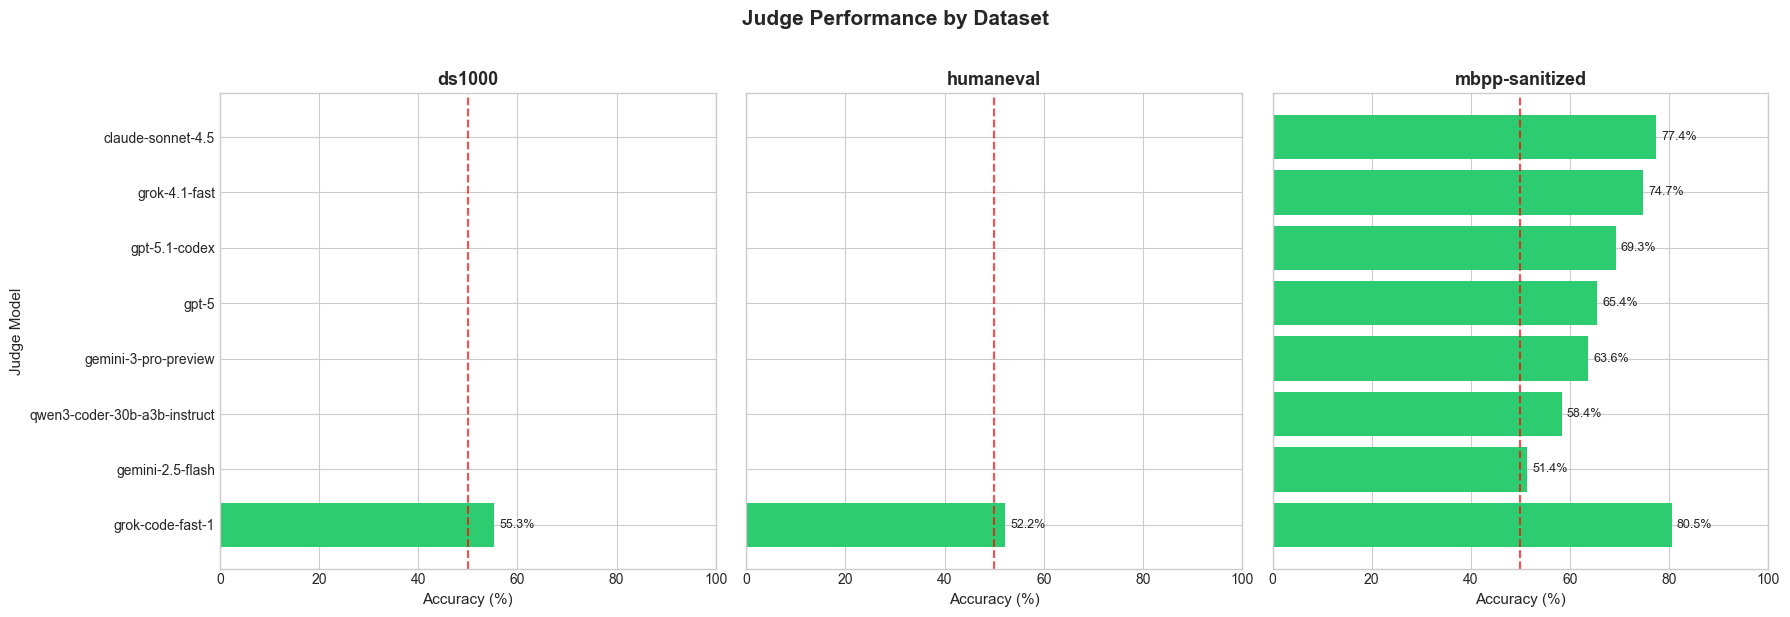

In [19]:
# Visualize per-dataset judge performance
fig, axes = plt.subplots(1, len(benchmarks), figsize=(6 * len(benchmarks), 6), sharey=True)

if len(benchmarks) == 1:
    axes = [axes]

for ax, benchmark in zip(axes, benchmarks):
    bench_df = df_valid[df_valid['benchmark'] == benchmark]
    
    # Get judge stats for this benchmark
    judge_stats_bench = bench_df.groupby('judge_short').agg(
        total=('is_correct', 'count'),
        correct=('is_correct', 'sum')
    ).reset_index()
    
    judge_stats_bench['accuracy'] = (judge_stats_bench['correct'] / judge_stats_bench['total'] * 100)
    judge_stats_bench = judge_stats_bench.sort_values('accuracy', ascending=True)
    
    # Create bar chart
    colors = ['#2ecc71' if acc > 50 else '#e74c3c' for acc in judge_stats_bench['accuracy']]
    bars = ax.barh(judge_stats_bench['judge_short'], judge_stats_bench['accuracy'], color=colors)
    
    # Add value labels
    for bar, acc in zip(bars, judge_stats_bench['accuracy']):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
                f'{acc:.1f}%', va='center', fontsize=9)
    
    ax.axvline(x=50, color='red', linestyle='--', alpha=0.7, linewidth=1.5)
    ax.set_xlabel('Accuracy (%)', fontsize=11)
    ax.set_title(f'{benchmark}', fontsize=13, fontweight='bold')
    ax.set_xlim(0, 100)

axes[0].set_ylabel('Judge Model', fontsize=11)
fig.suptitle('Judge Performance by Dataset', fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.show()


In [20]:
# Create detailed per-dataset summary tables
for benchmark in benchmarks:
    print("=" * 80)
    print(f"DETAILED SUMMARY: {benchmark.upper()}")
    print("=" * 80)
    
    bench_df = df_valid[df_valid['benchmark'] == benchmark]
    
    # Cross-tabulation: Judge × Model Pair accuracy
    cross_stats = bench_df.groupby(['judge_short', 'model_pair_str']).agg(
        total=('is_correct', 'count'),
        correct=('is_correct', 'sum')
    ).reset_index()
    
    cross_stats['accuracy'] = (cross_stats['correct'] / cross_stats['total'] * 100).round(1)
    
    # Create pivot table
    pivot = cross_stats.pivot(index='judge_short', columns='model_pair_str', values='accuracy')
    
    # Add overall column (before converting to string)
    overall = bench_df.groupby('judge_short')['is_correct'].mean() * 100
    pivot['Overall'] = overall.round(1)
    pivot = pivot.sort_values('Overall', ascending=False)
    
    # Convert to string and fill NaN for display
    pivot = pivot.astype(object).fillna('-')
    
    print(f"\nJudge × Model Pair Accuracy (%):")
    print(pivot.to_string())
    
    # Statistical test for this benchmark
    print(f"\nStatistical Significance (is accuracy > 50%?):")
    for judge in bench_df['judge_short'].unique():
        judge_data = bench_df[bench_df['judge_short'] == judge]
        n_correct = int(judge_data['is_correct'].sum())
        n_total = len(judge_data)
        
        if n_total >= 10:  # Only test if enough samples
            result = stats.binomtest(n_correct, n_total, p=0.5, alternative='greater')
            sig = "***" if result.pvalue < 0.001 else "**" if result.pvalue < 0.01 else "*" if result.pvalue < 0.05 else ""
            print(f"  {judge:35} p={result.pvalue:.4f} {sig}")
    
    print()


DETAILED SUMMARY: DS1000

Judge × Model Pair Accuracy (%):
model_pair_str    claude-haiku-4.5 vs deepseek-chat-v3-0324  Overall
judge_short                                                         
grok-code-fast-1                                       55.3     55.3

Statistical Significance (is accuracy > 50%?):
  grok-code-fast-1                    p=0.1103 

DETAILED SUMMARY: HUMANEVAL

Judge × Model Pair Accuracy (%):
model_pair_str    claude-haiku-4.5 vs deepseek-chat-v3-0324  claude-haiku-4.5 vs gpt-5  deepseek-chat-v3-0324 vs grok-4-fast  Overall
judge_short                                                                                                                          
grok-code-fast-1                                       64.6                       39.6                                  52.4     52.2

Statistical Significance (is accuracy > 50%?):
  grok-code-fast-1                    p=0.1719 

DETAILED SUMMARY: MBPP-SANITIZED

Judge × Model Pair Accuracy (%):
model_pai

/var/folders/l3/qgx9f5qn31xd885n0rf5gm2c0000gn/T/ipykernel_92440/3980251257.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pivot = pivot.astype(object).fillna('-')
/var/folders/l3/qgx9f5qn31xd885n0rf5gm2c0000gn/T/ipykernel_92440/3980251257.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  pivot = pivot.astype(object).fillna('-')
/var/folders/l3/qgx9f5qn31xd885n0rf5gm2c0000gn/T/ipykernel_92440/3980251257.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.

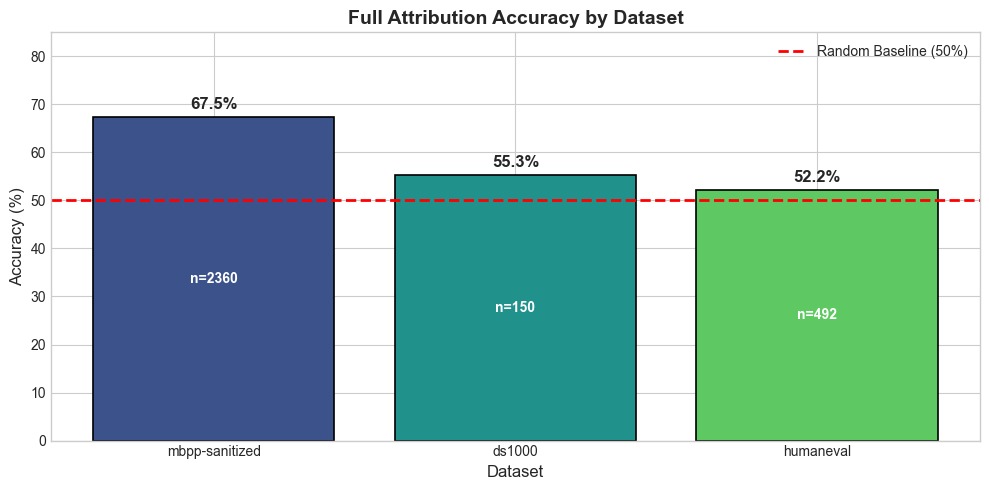


Dataset Summary:
--------------------------------------------------
  mbpp-sanitized        67.5% (n=2360) ✓ Above chance
  ds1000                55.3% (n= 150) ✓ Above chance
  humaneval             52.2% (n= 492) ✓ Above chance


In [21]:
# Dataset comparison: overall accuracy bar chart
fig, ax = plt.subplots(figsize=(10, 5))

dataset_stats = df_valid.groupby('benchmark').agg(
    total=('is_correct', 'count'),
    correct=('is_correct', 'sum')
).reset_index()

dataset_stats['accuracy'] = (dataset_stats['correct'] / dataset_stats['total'] * 100)
dataset_stats = dataset_stats.sort_values('accuracy', ascending=False)

colors = sns.color_palette('viridis', len(dataset_stats))
bars = ax.bar(dataset_stats['benchmark'], dataset_stats['accuracy'], color=colors, edgecolor='black', linewidth=1.2)

# Add value labels and sample counts
for bar, (_, row) in zip(bars, dataset_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{row["accuracy"]:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2, 
            f'n={row["total"]}', ha='center', va='center', fontsize=10, color='white', fontweight='bold')

ax.axhline(y=50, color='red', linestyle='--', linewidth=2, label='Random Baseline (50%)')
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_xlabel('Dataset', fontsize=12)
ax.set_title('Full Attribution Accuracy by Dataset', fontsize=14, fontweight='bold')
ax.legend()
ax.set_ylim(0, 85)

plt.tight_layout()
plt.show()

# Print summary
print("\nDataset Summary:")
print("-" * 50)
for _, row in dataset_stats.iterrows():
    status = "✓ Above chance" if row['accuracy'] > 50 else "✗ At/below chance"
    print(f"  {row['benchmark']:20} {row['accuracy']:5.1f}% (n={row['total']:4}) {status}")
